# Homework

## Dataset

In [1]:
!wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv

--2025-11-03 15:00:58--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8000::154, 2606:50c0:8002::154, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8001::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘car_fuel_efficiency.csv’

car_fuel_efficiency 100%[===================>] 853.70K  4.59MB/s    in 0.2s    

2025-11-03 15:00:59 (4.59 MB/s) - ‘car_fuel_efficiency.csv’ saved [874188/874188]



## Preparing the dataset 

Preparation:

* Fill missing values with zeros.
* Do train/validation/test split with 60%/20%/20% distribution. 
* Use the `train_test_split` function and set the `random_state` parameter to 1.
* Use `DictVectorizer(sparse=True)` to turn the dataframes into matrices.


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('car_fuel_efficiency.csv')

In [4]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [5]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [6]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [7]:
df = df.fillna(0)

In [8]:
df.isnull().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer

In [14]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)
y_full_train = df_full_train.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg
y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
df_test = df_test.drop(columns= ['fuel_efficiency_mpg'])
df_train = df_train.drop(columns=['fuel_efficiency_mpg'])
df_val = df_val.drop(columns=['fuel_efficiency_mpg'])


In [15]:

dv = DictVectorizer(sparse=True)
X_train = dv.fit_transform(df_train.to_dict(orient='records'))
X_val = dv.transform(df_val.to_dict(orient='records'))

## Question 1

Let's train a decision tree regressor to predict the `fuel_efficiency_mpg` variable. 

* Train a model with `max_depth=1`.


Which feature is used for splitting the data?


* `'vehicle_weight'`
* `'model_year'`
* `'origin'`
* `'fuel_type'`


In [16]:
from sklearn.tree import DecisionTreeRegressor, export_text

In [17]:
dt = DecisionTreeRegressor(max_depth=1)
dt.fit(X_train, y_train)
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



A/ `vehicle_weight`

## Question 2

Train a random forest regressor with these parameters:

* `n_estimators=10`
* `random_state=1`
* `n_jobs=-1` (optional - to make training faster)


What's the RMSE of this model on the validation data?

* 0.045
* 0.45
* 4.5
* 45.0

In [18]:
from sklearn.ensemble import RandomForestRegressor

In [19]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10, n_jobs=-1, random_state=1)

In [20]:
import numpy as np

In [21]:
def rmse(y, y_pred):
    squared_error = (y - y_pred)**2
    mse = np.mean(squared_error)
    return np.sqrt(mse)


In [26]:
y_pred = rf.predict(X_val)
print(round(rmse(y_val, y_pred), 3))

0.459


A/ `0.459`

## Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

- 10
- 25
- 80
- 200

If it doesn't stop improving, use the latest iteration number in
your answer.

In [29]:
for n_estimators in np.arange(10, 210, 10):
    rf = RandomForestRegressor(n_estimators=n_estimators, random_state=1, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_val)
    print(n_estimators, "=>", round(rmse(y_val, y_pred), 3))

10 => 0.459
20 => 0.454
30 => 0.451
40 => 0.448
50 => 0.446
60 => 0.445
70 => 0.445
80 => 0.445
90 => 0.445
100 => 0.445
110 => 0.444
120 => 0.444
130 => 0.444
140 => 0.444
150 => 0.443
160 => 0.443
170 => 0.443
180 => 0.443
190 => 0.443
200 => 0.443


A/ `200`

## Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE 
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

* 10
* 15
* 20
* 25

In [32]:
scores = []
for max_depth in [10, 15, 20, 25]:
    for n_estimators in np.arange(10, 210, 10):
        rf = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        scores.append([max_depth, n_estimators, round(rmse(y_val, y_pred), 3)])

df_scores = pd.DataFrame(data=scores, columns=['max_depth', 'n_estimators', 'rmse'])
df_scores[df_scores['rmse'] == df_scores['rmse'].min()]

,max_depth,n_estimators,rmse
13,10,140,0.44
14,10,150,0.44
15,10,160,0.44
16,10,170,0.44
17,10,180,0.44
18,10,190,0.44
19,10,200,0.44


In [33]:
for max_depth in [10, 15, 20, 25]:
    scores = []
    for n_estimators in np.arange(10, 210, 10):
        rf = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=1, n_jobs=-1)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_val)
        scores.append(round(rmse(y_val, y_pred), 3))
    print(max_depth, '=>', np.array(scores).mean())

10 => 0.442
15 => 0.44559999999999994
20 => 0.4457
25 => 0.4457999999999999


A/ `10`

# Question 5

We can extract feature importance information from tree-based models. 

At each step of the decision tree learning algorithm, it finds the best split. 
When doing it, we can calculate "gain" - the reduction in impurity before and after the split. 
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field. 

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model


What's the most important feature (among these 4)? 

* `vehicle_weight`
*	`horsepower`
* `acceleration`
* `engine_displacement`	

In [34]:
from matplotlib import pyplot as plt

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'acceleration'),
  Text(1, 0, 'drivetrain=All-wheel drive'),
  Text(2, 0, 'drivetrain=Front-wheel drive'),
  Text(3, 0, 'engine_displacement'),
  Text(4, 0, 'fuel_type=Diesel'),
  Text(5, 0, 'fuel_type=Gasoline'),
  Text(6, 0, 'horsepower'),
  Text(7, 0, 'model_year'),
  Text(8, 0, 'num_cylinders'),
  Text(9, 0, 'num_doors'),
  Text(10, 0, 'origin=Asia'),
  Text(11, 0, 'origin=Europe'),
  Text(12, 0, 'origin=USA'),
  Text(13, 0, 'vehicle_weight')])

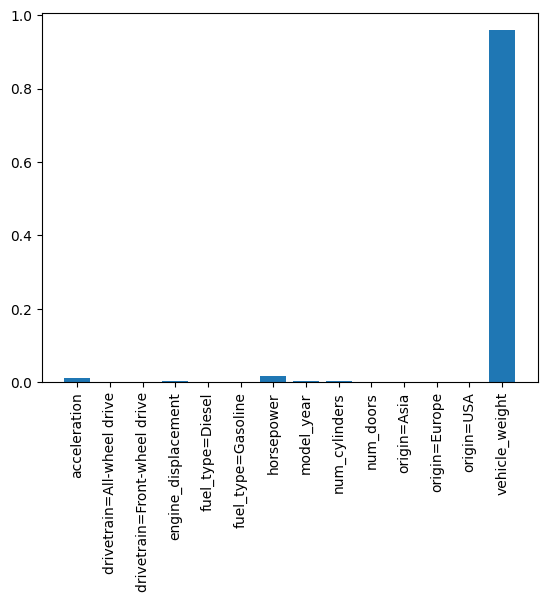

In [35]:
n_estimators = 10
max_depth = 20
random_state = 1
n_jobs = -1

rf = RandomForestRegressor(n_estimators=n_estimators, max_depth=max_depth, random_state=random_state, n_jobs=n_jobs)
rf.fit(X_train, y_train)


plt.bar(dv.get_feature_names_out(), rf.feature_importances_)
plt.xticks(rotation=90)


A/ `vehicle_weight`

## Question 6

Now let's train an XGBoost model! For this question, we'll tune the `eta` parameter:

* Install XGBoost
* Create DMatrix for train and validation
* Create a watchlist
* Train a model with these parameters for 100 rounds:

```
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}
```

Now change `eta` from `0.3` to `0.1`.

Which eta leads to the best RMSE score on the validation dataset?

* 0.3
* 0.1
* Both give equal value

In [36]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(":")[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))
    
    columns = ['num_iter', 'train_rmse', 'val_rmse']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results


In [37]:
!uv add xgboost

Resolved 71 packages in 611ms                                        
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)--------------     0 B/2.11 MiB            
⠙ Preparing packages... (0/1)-------------- 16.00 KiB/2.11 MiB          
⠙ Preparing packages... (0/1)-------------- 32.00 KiB/2.11 MiB          
⠙ Preparing packages... (0/1)-------------- 48.00 KiB/2.11 MiB          
⠙ Preparing packages... (0/1)-------------- 60.63 KiB/2.11 MiB          
⠙ Preparing packages... (0/1)-------------- 76.63 KiB/2.11 MiB          
⠙ Preparing packages... (0/1)-------------- 92.63 KiB/2.11 MiB          
⠹ Preparing packages... (0/1)-------------- 108.63 KiB/2.11 MiB         
⠹ Preparing packages... (0/1)-------------- 108.63 KiB/2.11 MiB         
⠹ Preparing packages... (0/1)-------------- 124.63 KiB/2.11 MiB         
⠹ Preparing packages... (0/1)-------------- 140.63 KiB/2.11 MiB         
⠹ Preparing packages... (0/1)-------------- 15

In [38]:
import xgboost as xgb

In [39]:
features = dv.get_feature_names_out()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(features))
dval = xgb.DMatrix(X_val, label=y_val, feature_names=list(features))
watchlist = [(dtrain, 'train'), (dval, 'val')]
output = ''
scores = {}

In [40]:
xgb_params = {
    'eta': 0.3, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

In [43]:
%%capture output

model = xgb.train(xgb_params, dtrain, num_boost_round=100, verbose_eval=5, evals=watchlist)

In [44]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)

In [46]:
xgb_params = {
    'eta': 0.1, 
    'max_depth': 6,
    'min_child_weight': 1,
    
    'objective': 'reg:squarederror',
    'nthread': 8,
    
    'seed': 1,
    'verbosity': 1,
}

In [47]:
%%capture output

model = xgb.train(xgb_params, dtrain, num_boost_round=100, verbose_eval=5, evals=watchlist)

In [48]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)

In [49]:
print('eta=0.3', '=>', round(scores['eta=0.3']['val_rmse'].mean(), 3))

eta=0.3 => 0.515


In [50]:
print('eta=0.1', '=>', round(scores['eta=0.1']['val_rmse'].mean(), 3))

eta=0.1 => 0.61


A/ `0.3`